# Capstone Two: Data Wrangling
## Class A/B/C Multifamily Risk Score in USA
**Author:** Daksha Gummadi

This notebook performs data wrangling for my multifamily real estate risk assessment capstone project. I am building a risk scoring model to compare Class A, B and C apartment properties across the United States. 

**Data Sources Used:**
- Zillow ZORI (Observed Rent Index)
- FRED Rental Vacancy Rate
- FRED Building Permits

## Table of Contents

1. [Import Libraries](#import-libraries)
2. [Load Data](#load-data)
   - [Zillow ZORI Data](#zillow-zori-data)
   - [Vacancy Rate Data](#vacancy-rate-data)
   - [Building Permits Data](#building-permits-data)
3. [Reshape ZORI Data](#reshape-zori-data)
4. [National Average Rent](#national-average-rent)
5. [Convert Quarterly Vacancy to Monthly](#convert-quarterly-vacancy-to-monthly)
6. [Merge All Data](#merge-all-data)
7. [Calculate Year Over Year Rent Growth](#calculate-year-over-year-rent-growth)
8. [Create Property Class Segments](#create-property-class-segments)
9. [Class Specific Averages](#class-specific-averages)
10. [Class Specific Growth Rates](#class-specific-growth-rates)
11. [Time Features](#time-features)
12. [Summary Stats](#summary-stats)
    - [Summary by Property Class](#summary-by-property-class)
13. [Data Quality Checks](#data-quality-checks)
14. [Visualizations](#visualizations)
15. [Final Dataset Summary](#final-dataset-summary)
16. [Conclusion](#conclusion)

## 1. Import Libraries

**Libraries I'm using:**

- os: This library helps me work with files on my computer to manage file paths.
- pandas (pd): This library lets me load CSV files, work with data in table format called dataframes, filter data, merge datasets and perform calculations. 
- numpy (np): This library provides mathematical functions and operations. I use it for numerical calculations, working with arrays and performing statistical operations.
- matplotlib.pyplot (plt): This library creates charts and graphs. I'll use it to visualize my data and see trends over time.

In [98]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

In [6]:
#pip install missingno

## 2. Load Data

In this section, I load 3 CSV files that contain the raw data for my analysis. Each dataset comes from a different source and contains different information about the multifamily rental market.

### Zillow ZORI Data
*Data Source:* Zillow Research Observed Rent Index (ZORI)  
https://www.zillow.com/research/data/

This data set contains the Zillow Observed Rent Index (ZORI) measures typical rent prices for multifamily properties across 544 metropolitan areas in the United States. The data is adjusted to show clear trends. Each row represents one metro area and each column represents a month from 2015 to 2025. The values are in dollars and represent the typical monthly rent for that metro in that month. Rent levels are the foundation of my analysis. By seeing how rents differ across metros, I can classify properties into Class A (expensive), Class B (mid-range) and Class C (affordable) categories. I can also calculate rent growth rates to measure market performance.

In [20]:
# Load ZORI metro rent data
zori = pd.read_csv('ZORI.csv')  #read the file and store it in a variable called 'zori'
print(zori.shape) #prints how many rows and columns we have
zori.head() #shows the rows so we can see what the data looks like

(544, 137)


,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31
0,102001,0,United States,country,NaN,1133.731984,1140.842483,1151.491726,1160.033277,1169.166164,...,1741.991065,1752.625204,1760.157451,1764.336689,1765.122255,1763.668003,1759.999943,1754.196322,1746.749782,1741.252791
1,394913,1,"New York, NY",msa,NY,2138.171808,2150.760266,2168.721822,2189.520988,2208.135902,...,3094.573944,3124.006867,3150.263404,3181.819213,3212.506185,3234.750295,3231.961016,3218.066769,3192.622168,3178.930447
2,753899,2,"Los Angeles, CA",msa,CA,1650.480148,1663.198362,1679.338522,1697.632972,1711.599397,...,2646.787779,2652.945031,2658.214796,2663.500267,2664.673610,2665.921498,2665.460541,2664.282373,2655.906124,2646.376452
3,394463,3,"Chicago, IL",msa,IL,1304.813747,1311.902202,1321.136646,1328.459786,1338.305502,...,1909.200625,1932.860943,1952.495911,1971.280014,1979.364323,1981.099793,1976.849190,1970.494752,1965.523589,1962.269835
4,394514,4,"Dallas, TX",msa,TX,1022.032360,1015.534937,1021.449858,1039.959308,1051.707029,...,1510.271466,1520.176097,1522.803851,1522.471741,1517.940631,1514.210173,1508.431221,1501.215235,1494.662312,1490.557604


In [86]:
zori.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544 entries, 0 to 543
Columns: 137 entries, RegionID to 2025-12-31
dtypes: float64(132), int64(2), object(3)
memory usage: 582.4+ KB


This shows the structure of the original ZORI dataset before reshaping. The dataset has 544 rows (one for each metro area) and 137 columns. The columns include 5 identifier columns (RegionID, SizeRank, RegionName, RegionType, StateName) plus 132 date columns from 2015-01-31 to 2025-12-31. The data types show 132 float columns (the rent values), 2 integer columns (RegionID and SizeRank), and 3 object columns (text data for metro names and types). 

In [94]:
zori.describe()

,RegionID,SizeRank,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,2015-06-30,2015-07-31,2015-08-31,...,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31
count,544.000000,544.000000,99.000000,99.000000,100.000000,100.000000,102.000000,102.000000,104.000000,104.000000,...,454.000000,455.000000,461.000000,463.000000,473.000000,474.000000,478.000000,489.000000,498.000000,544.000000
mean,412522.511029,304.582721,996.668083,1000.384035,1007.759155,1016.101868,1017.170865,1023.753094,1024.824362,1028.359845,...,1355.376008,1361.884909,1366.753558,1370.295198,1365.321191,1368.015698,1368.701149,1359.861725,1350.757262,1328.643619
std,83207.373659,205.992170,337.594121,339.462864,342.060123,346.888250,354.265444,358.695483,362.354237,364.750631,...,456.724408,459.073266,457.085737,458.107666,456.025970,453.707186,451.376537,448.473306,446.649742,439.547800
min,102001.000000,0.000000,577.059368,580.862739,588.047806,588.902675,536.743523,547.528425,569.009449,560.163985,...,641.976122,657.740118,653.125278,664.509055,665.128763,668.517025,653.274995,655.797724,660.529242,600.000000
25%,394541.500000,136.750000,783.613789,783.885944,790.170328,795.895766,797.938338,797.248443,791.528686,799.679689,...,1029.872379,1036.723939,1046.180006,1044.743876,1033.592719,1047.937646,1054.635009,1040.087400,1029.874815,1008.250000
50%,394776.500000,275.500000,937.293981,944.324490,949.497735,948.878893,948.793805,956.514774,946.272456,952.317270,...,1265.442330,1269.734417,1270.752481,1274.919101,1277.482579,1285.654231,1276.220494,1277.362322,1263.371338,1247.870166
75%,395045.500000,444.250000,1083.539858,1089.568701,1095.887258,1104.622472,1112.408236,1117.782639,1116.739626,1116.346278,...,1550.138683,1562.503589,1567.478962,1574.642547,1568.426965,1563.666491,1562.513330,1551.500446,1548.495224,1527.830357
max,845167.000000,921.000000,2424.174582,2423.042479,2433.394856,2474.156810,2546.046366,2597.802226,2654.467556,2674.642330,...,3152.389708,3177.823318,3203.467202,3227.839263,3246.377175,3264.932502,3261.896913,3251.028736,3238.611689,3243.098624


This table shows statistics for all 137 columns in ZORI data. Show there are 544 metros with IDs ranging from 102001 to 845167. For the rent columns the count row shows how many metros have data for each date. Early dates like 2015-01-31 only have 99 metros with data while recent dates like 2025-12-31 have all 544 metros. The mean row shows average rent across all metros increased from about $997 in 2015 to $1,329 in December 2025. The standard deviation shows rent varies widely across metros (around $340-$460) because some metros like New York or San Francisco are much more expensive than smaller markets. The min and max rows show the cheapest metro had rents around $536-$668 while the most expensive metro had rents from $2,424 to $3,264 over the time period.

<Axes: >

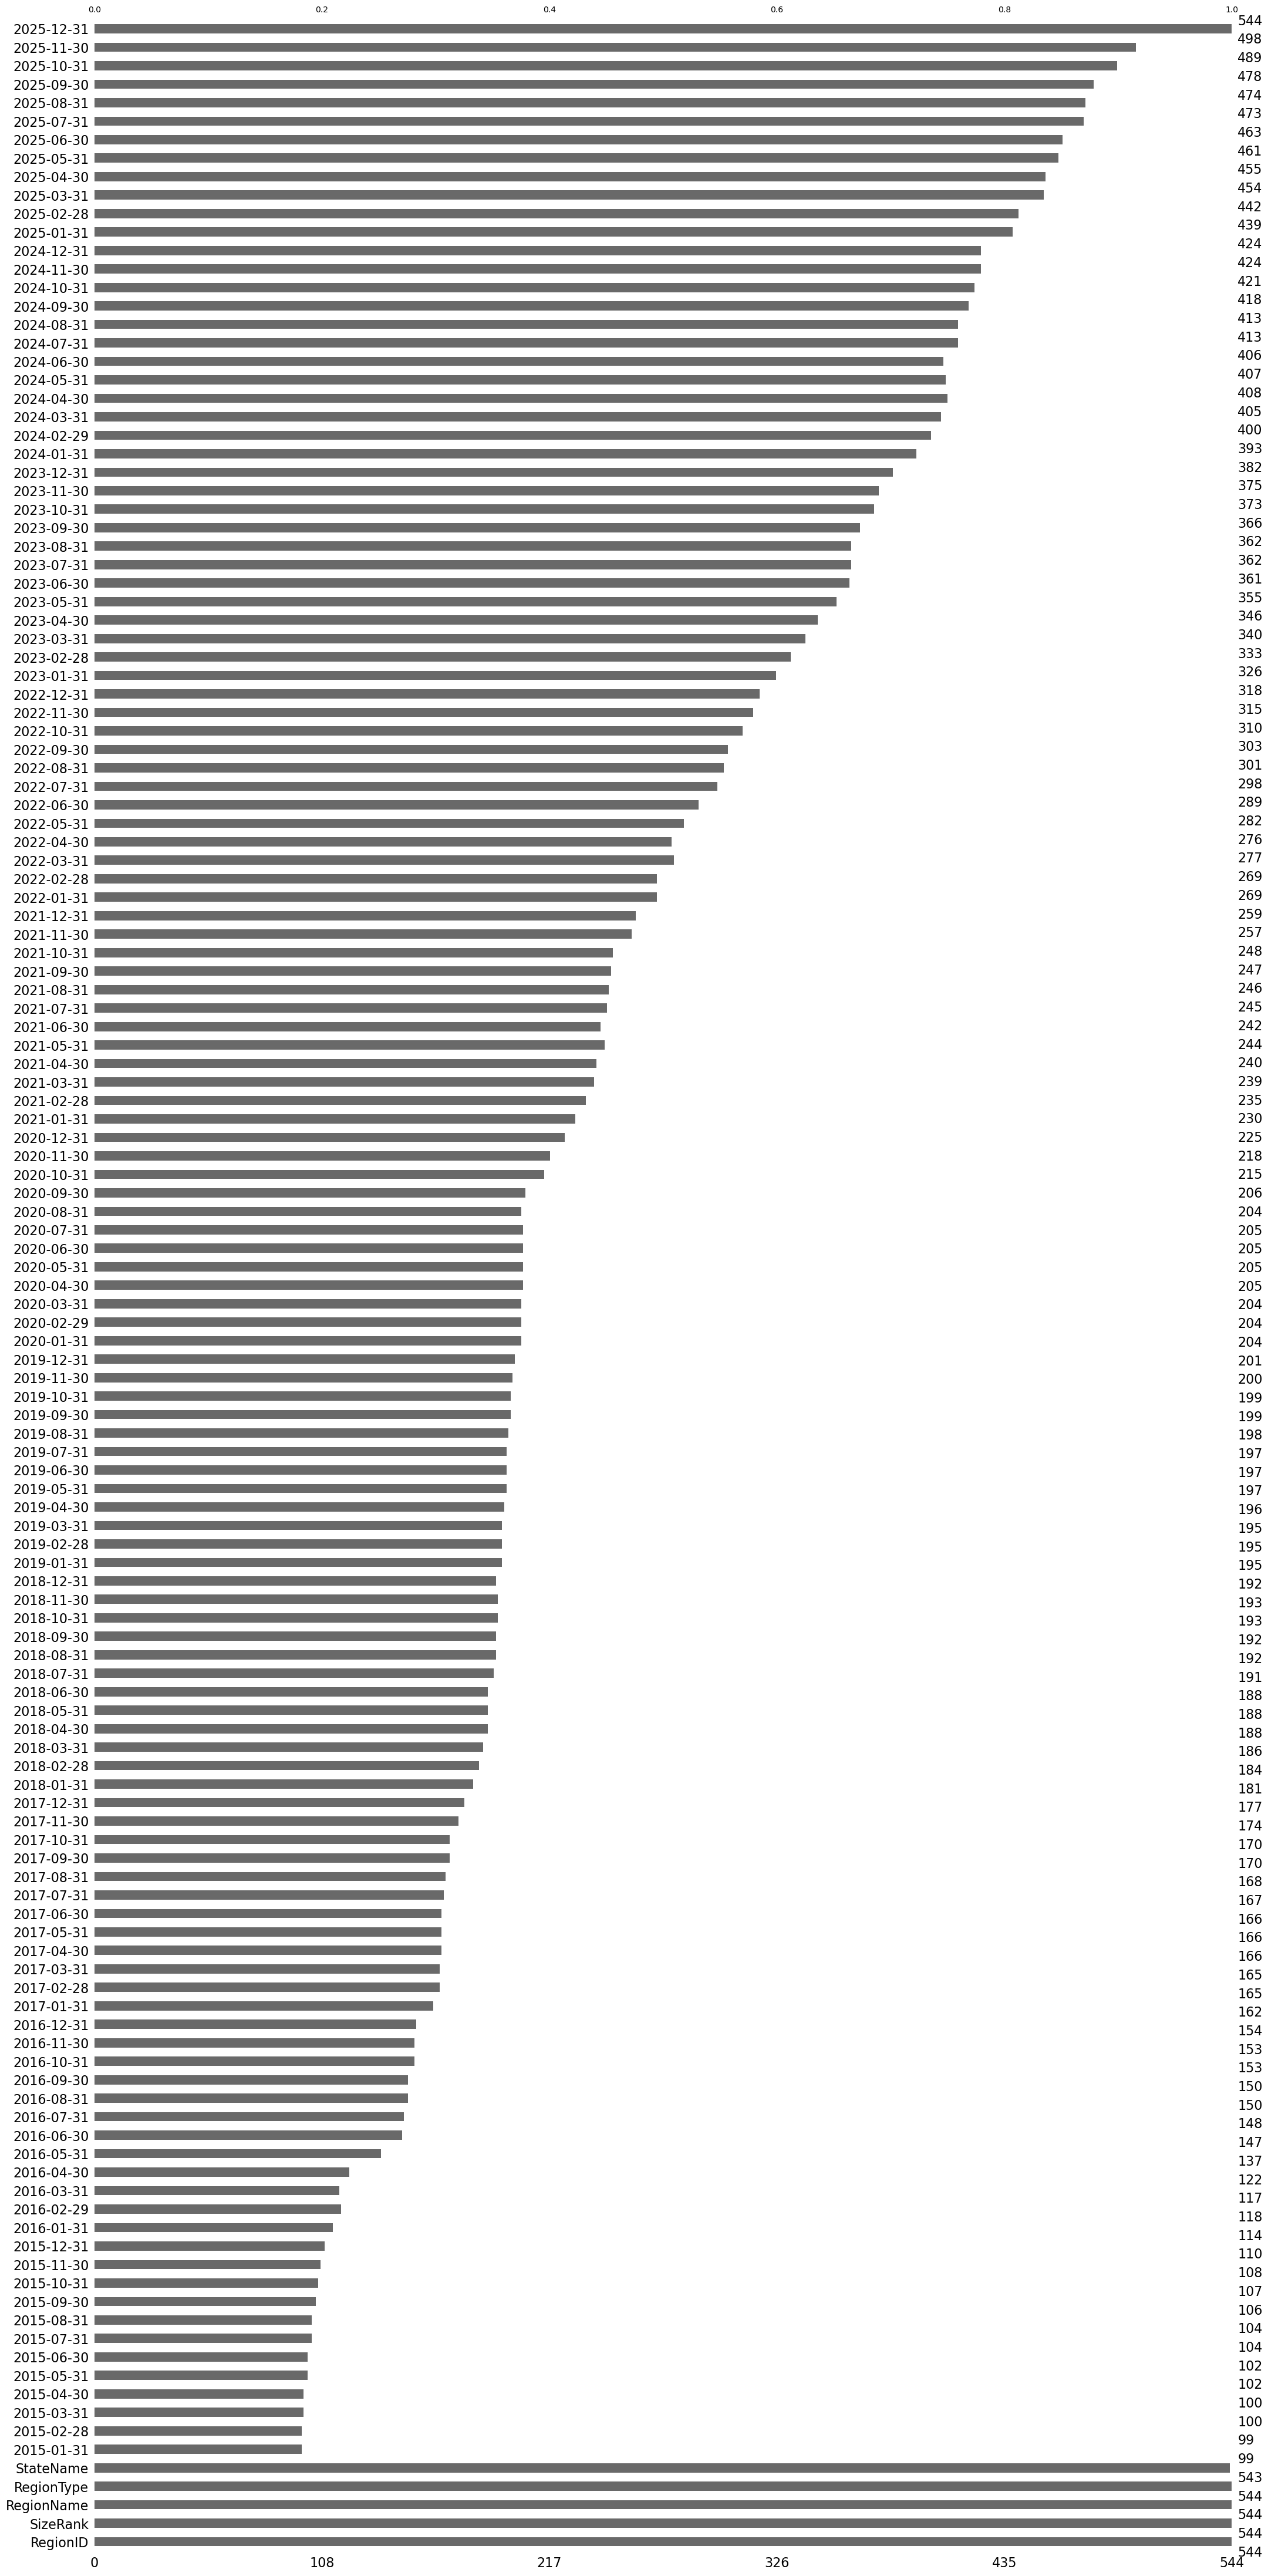

In [104]:
msno.bar(zori)

Shows data availability over time. Each bar represents one month/date. The bars get progressively longer from 2015 to 2025 showing we have more complete data in recent years. The bottom rows (RegionID, RegionType, RegionName, SizeRank) show bars go all the way across confirming all metro identifiers are present.

### Vacancy Rate Data
*Data Source:* Federal Reserve Economic Data (FRED) Rental Vacancy Rate  
https://fred.stlouisfed.org/series/RRVRUSQ156N
  
This dataset shows the national rental vacancy rate which is the percentage of all rental housing units that are vacant and available for rent. The data comes from the U.S. Census Bureau's Housing Vacancy Survey and is reported every 3 months. A vacancy rate of 6.6% means that 6.6 out of every 100 rental units are empty. Vacancy rate is a key indicator of rental market health. High vacancy rates suggest weak demand and potential rent decreases. Low vacancy rates suggest strong demand and potential rent increases. This helps me assess risk.

In [21]:
# Load vacancy rate
vacancy = pd.read_csv('RRVRUSQ156N.csv') #reads vacancy rate file
vacancy = vacancy.rename(columns={'observation_date':'date', 'RRVRUSQ156N':'vacancy_rate'}) #'observation_date' becomes 'date' and 'RRVRUSQ156N' becomes 'vacancy_rate'
vacancy['date'] = pd.to_datetime(vacancy['date']) #converts the date column from text to actual dates that python understands

print(vacancy.shape)
vacancy.head()

(24, 2)


,date,vacancy_rate
0,2020-01-01,6.6
1,2020-04-01,5.7
2,2020-07-01,6.4
3,2020-10-01,6.5
4,2021-01-01,6.8


In [108]:
vacancy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          24 non-null     datetime64[ns]
 1   vacancy_rate  24 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 516.0 bytes


<Axes: >

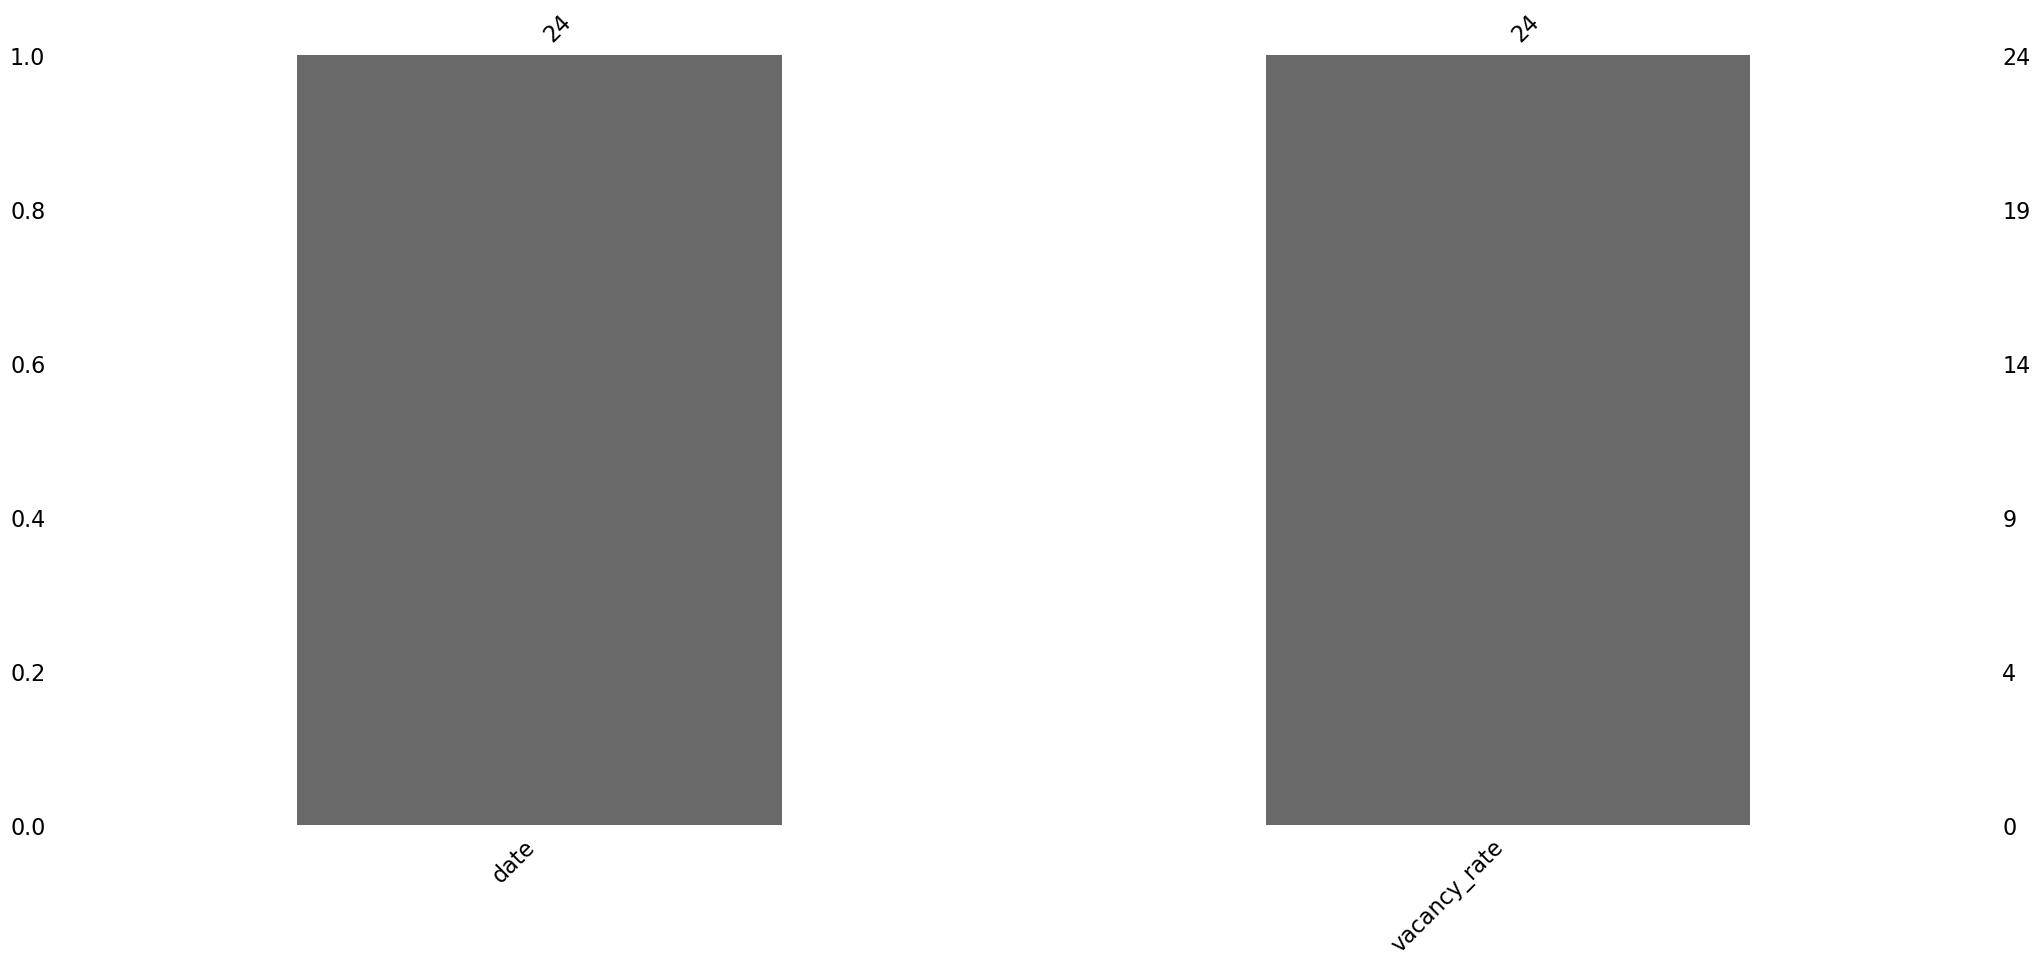

In [110]:
msno.bar(vacancy)

Shows date and vacancy_rate columns both have 100% complete data (24 rows). This is  original quarterly vacancy data before interpolation showing all 24 quarters are present.

### Building Permits Data
*Data Source:* Federal Reserve Economic Data (FRED) New Private Housing Units Authorized by Building Permits  
https://fred.stlouisfed.org/series/PERMIT
 
This dataset tracks the number of new housing construction permits issued each month across the United States. Building permits are required before new construction can begin, so this data tells us how much new supply will enter the market. The numbers are reported in thousands so for example, 1495 means 1,495,000 permits were issued. New supply affects future rent prices and vacancy rates. If many new apartments are being built, it could increase competition and put downward pressure on rents with rent declines.

In [22]:
# Load building permits
permits = pd.read_csv('PERMIT.csv') #reads permt file
permits = permits.rename(columns={'observation_date':'date', 'PERMIT':'permits'}) #same as above, renames columns into simpler names
permits['date'] = pd.to_datetime(permits['date'])
print(permits.shape)
permits.head()

(70, 2)


,date,permits
0,2020-01-01,1495
1,2020-02-01,1455
2,2020-03-01,1346
3,2020-04-01,1076
4,2020-05-01,1250


<Axes: >

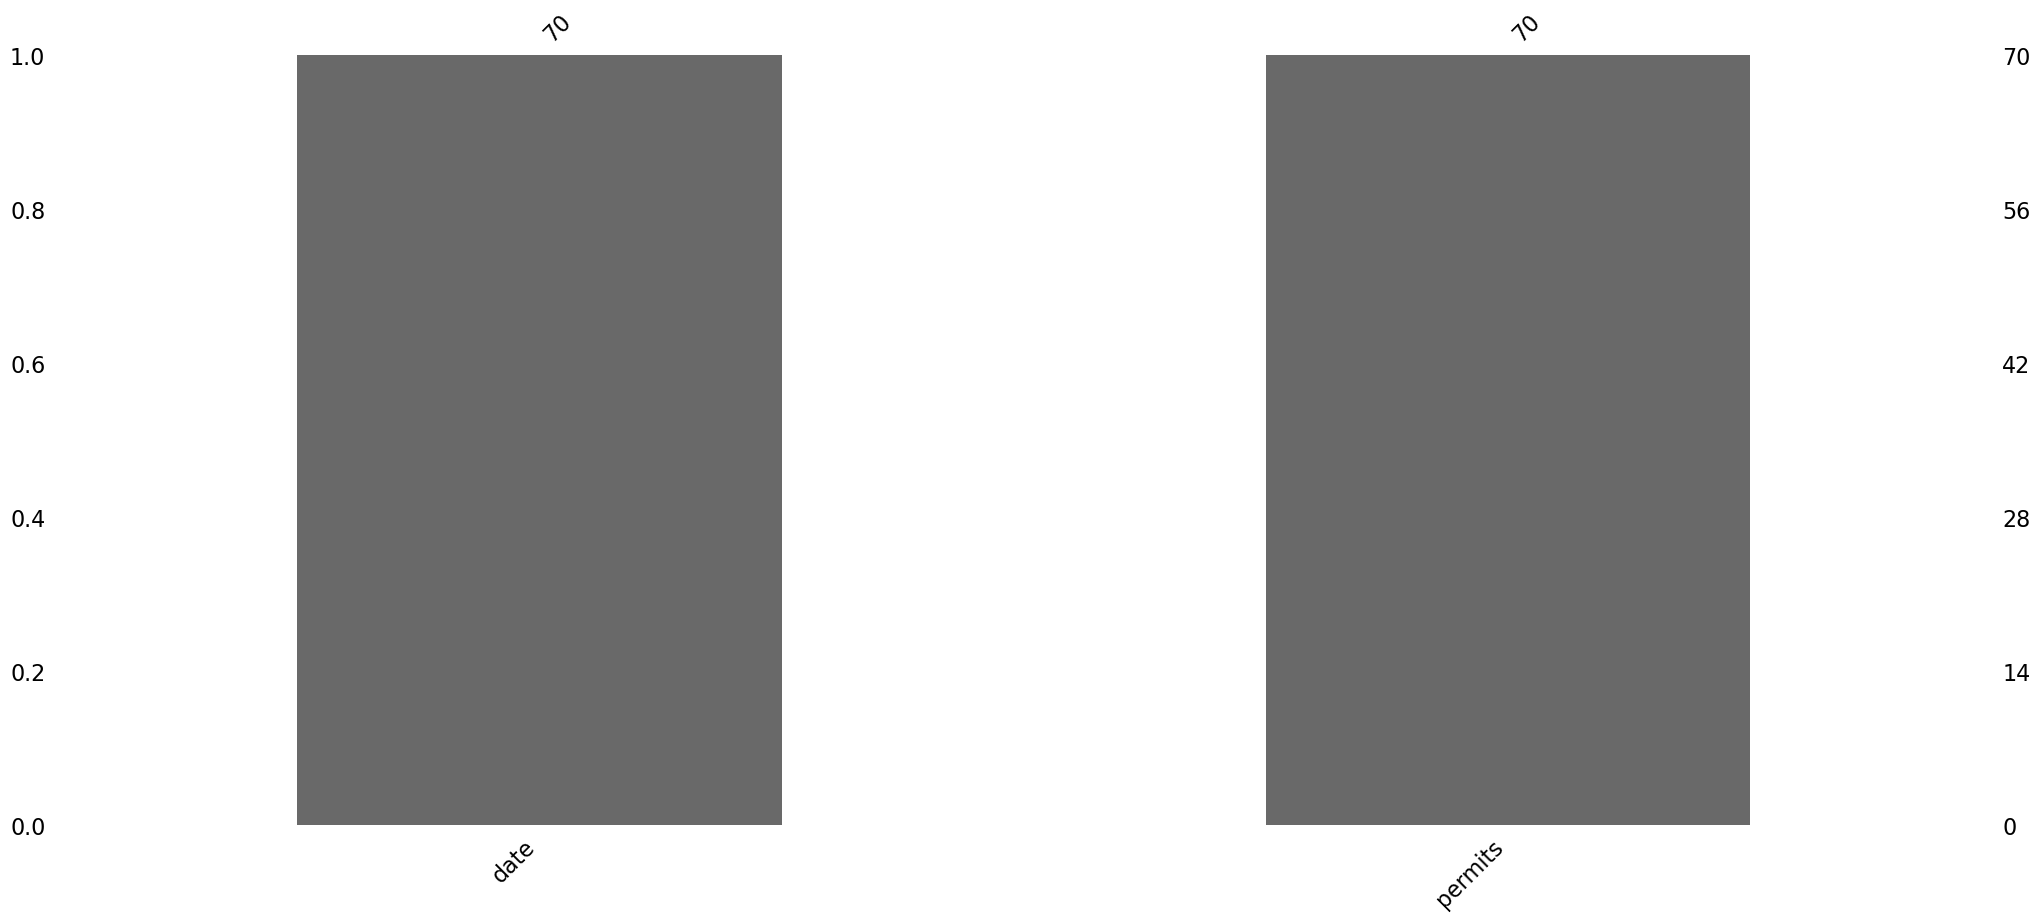

In [112]:
msno.bar(permits)

Shows columns both have 100% complete data (70 rows). This means my building permits data merged successfully with no missing values.

## 3. Reshape ZORI Data
The ZORI data is in wide format where each date is a separate column. This makes it hard to filter by date or merge with other datasets. I need to convert it to long format where each row represents one metro area in one month with a single date column and single rent column. I identify which columns are metro information and which are dates. Then I use pd.melt() to reshape the data and convert the date column to datetime format. I filter to keep only 2020 onwards and remove any rows with missing rent data.

In [23]:
#reshape zori wide to long format
id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName'] #identifies which columns contain information about the metros (not dates)

date_cols = [col for col in zori.columns if col not in id_cols] #gets all the date columns (everything except the ID columns) so this creates a list of all column names that aren't in id_cols

zori_long = pd.melt(zori, # the dataframe we're reshaping
                    id_vars=id_cols, #columns to keep as is
                    value_vars=date_cols,  #columns to convert to rows
                    var_name='date',  #names the new column that will hold the dates
                    value_name='rent') #the new column that will hold the rent values
zori_long['date'] = pd.to_datetime(zori_long['date']) #this converts the date column from text to actual dates


#filter to 2020 onwards
zori_long = zori_long[zori_long['date'] >= '2020-01-01']

#drop missing values
zori_long = zori_long.dropna(subset=['rent'])

print(zori_long.shape)
zori_long.head()

(23822, 7)


,RegionID,SizeRank,RegionName,RegionType,StateName,date,rent
32640,102001,0,United States,country,NaN,2020-01-31,1366.790675
32641,394913,1,"New York, NY",msa,NY,2020-01-31,2428.816367
32642,753899,2,"Los Angeles, CA",msa,CA,2020-01-31,2179.929265
32643,394463,3,"Chicago, IL",msa,IL,2020-01-31,1485.127590
32644,394514,4,"Dallas, TX",msa,TX,2020-01-31,1257.340995


In [139]:
zori_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23822 entries, 32640 to 71807
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   RegionID    23822 non-null  int64         
 1   SizeRank    23822 non-null  int64         
 2   RegionName  23822 non-null  object        
 3   RegionType  23822 non-null  object        
 4   StateName   23750 non-null  object        
 5   date        23822 non-null  datetime64[ns]
 6   rent        23822 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 1.5+ MB


In [143]:
zori_long.describe()

,RegionID,SizeRank,date,rent
count,23822.000000,23822.000000,23822,23822.000000
mean,411214.509613,202.523340,2023-07-11 09:14:25.922256640,1306.133836
min,102001.000000,0.000000,2020-01-31 00:00:00,568.221421
25%,394530.000000,83.000000,2022-02-28 00:00:00,997.467754
50%,394792.000000,171.000000,2023-09-30 00:00:00,1218.211391
75%,395050.000000,284.000000,2024-12-31 00:00:00,1520.484672
max,845167.000000,921.000000,2025-12-31 00:00:00,3264.932502
std,82353.823370,155.117991,NaN,434.386468


<Axes: >

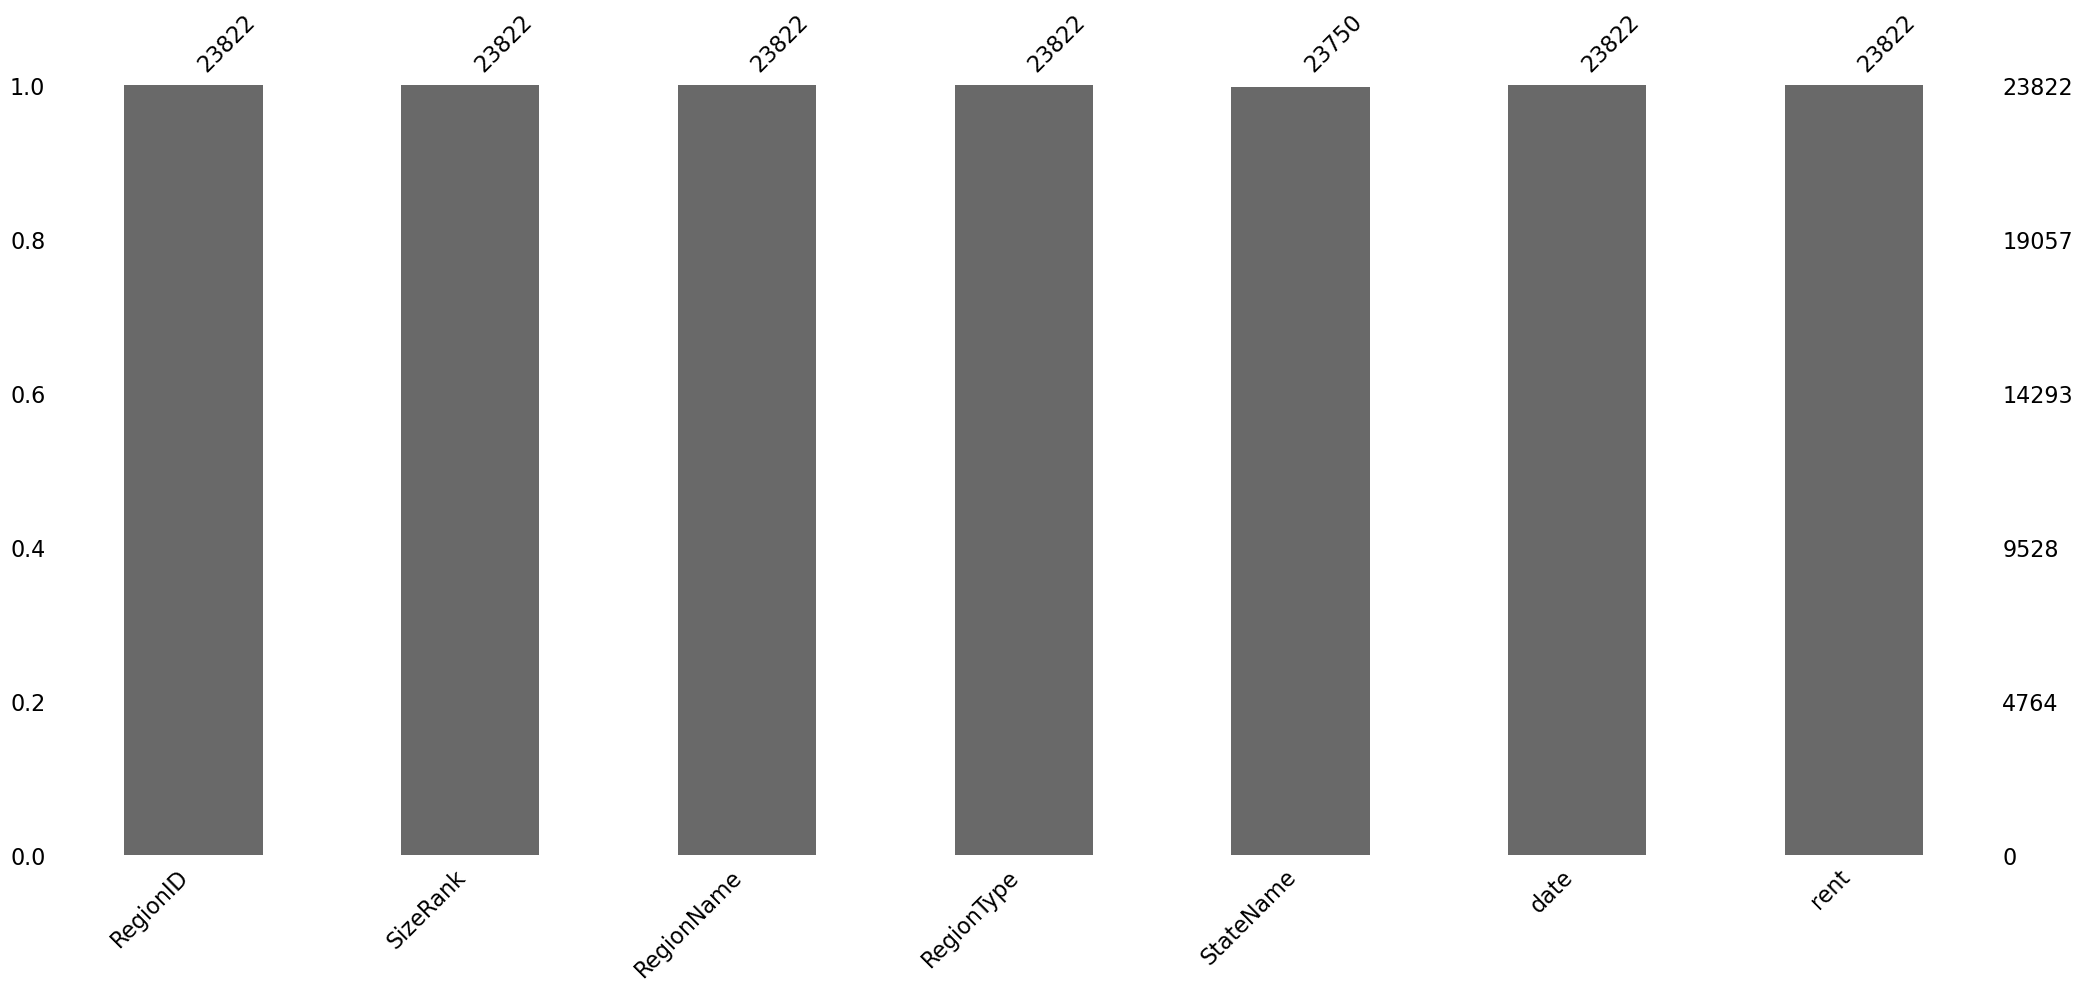

In [127]:
msno.bar(zori_long)

Shows the columns all have 100% complete data (23,822 rows). All bars go to the top meaning no missing values in the reshaped metro level data.

## 4. National Average Rent
I have rent data for 544 metro areas but I need national trends for my risk model so I calculate the average rent across all metros for each month. I group the data by date and calculate the average then create a new dataframe with just date and national average rent. The ZORI data has dates at the end of each month like 2020-01-31 but the vacancy and permits data use the beginning of the month like 2020-01-01. The dates need to match exactly for merging so I convert all ZORI dates to the first of the month.

In [80]:
#calculate & create national average rent by month
national_rent = zori_long.groupby('date')['rent'].mean().reset_index() #groupby('date') groups all rows with the same date together - ['rent'].mean() calculates the average rent for each date - reset_index() turns it back into a regular table
national_rent.columns = ['date', 'avg_rent'] #rename to make it more clear
national_rent['date'] = national_rent['date'].dt.to_period('M').dt.to_timestamp() #dt.to_period('M') converts to month period - dt.to_timestamp() converts back to timestamp but as first of month
print(national_rent.shape)
national_rent.head(10)

(72, 2)


,date,avg_rent
0,2020-01-01,1144.559911
1,2020-02-01,1150.840542
2,2020-03-01,1157.791469
3,2020-04-01,1155.929327
4,2020-05-01,1154.101083
5,2020-06-01,1155.181646
6,2020-07-01,1160.741194
7,2020-08-01,1144.482299
8,2020-09-01,1155.257865
9,2020-10-01,1165.048501


In [145]:
national_rent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      72 non-null     datetime64[ns]
 1   avg_rent  72 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.3 KB


In [147]:
national_rent.describe()

,date,avg_rent
count,72,72.000000
mean,2022-12-16 06:40:00,1288.077455
min,2020-01-01 00:00:00,1144.482299
25%,2021-06-23 12:00:00,1241.224204
50%,2022-12-16 12:00:00,1320.462680
75%,2024-06-08 12:00:00,1344.401395
max,2025-12-01 00:00:00,1370.295198
std,NaN,75.717553


This table shows summary statistics for my dataset. I have 72 months of data from January 2020 to December 2025. The average rent across all months is \\$1,288 with a minimum of \\$1,144 and maximum of \\$1,370. The standard deviation of \\$76 shows rent varied by about that much around the average. The date statistics confirm my data spans evenly from 2020 to 2025 with the median date in December 2022.

## 5. Convert Quarterly Vacancy to Monthly
The vacancy rate data is reported quarterly but my rent and permits data are monthly. To merge everything together I need all datasets to have the same monthly frequency. I use interpolation to estimate the vacancy rate for the months between quarterly observations. Interpolation draws a straight line between known values to fill in the gaps. I create a complete list of all months from the first to last vacancy date then merge this with the actual vacancy data and use interpolation to fill in the missing months. 

In [25]:
#create monthly date range and convert quarterly vacancy to monthly
#starts from the earliest date in vacancy data
# end at the latest date in vacancy data
date_range = pd.date_range(start=vacancy['date'].min(), 
                           end=vacancy['date'].max(), freq='MS') #MS means "Month Start" so the first day of each month
monthly_dates = pd.DataFrame({'date': date_range}) #turns this list into a dataframe with one column called 'date'
vacancy_monthly = monthly_dates.merge(vacancy, on='date', how='left')   #keeps all dates from monthly_dates even if no vacancy data
vacancy_monthly['vacancy_rate'] = vacancy_monthly['vacancy_rate'].interpolate() #interpolate estimates the missing values by drawing a line between known values
print(vacancy_monthly.shape)
vacancy_monthly.head(10)

(70, 2)


,date,vacancy_rate
0,2020-01-01,6.600000
1,2020-02-01,6.300000
2,2020-03-01,6.000000
3,2020-04-01,5.700000
4,2020-05-01,5.933333
5,2020-06-01,6.166667
6,2020-07-01,6.400000
7,2020-08-01,6.433333
8,2020-09-01,6.466667
9,2020-10-01,6.500000


<Axes: >

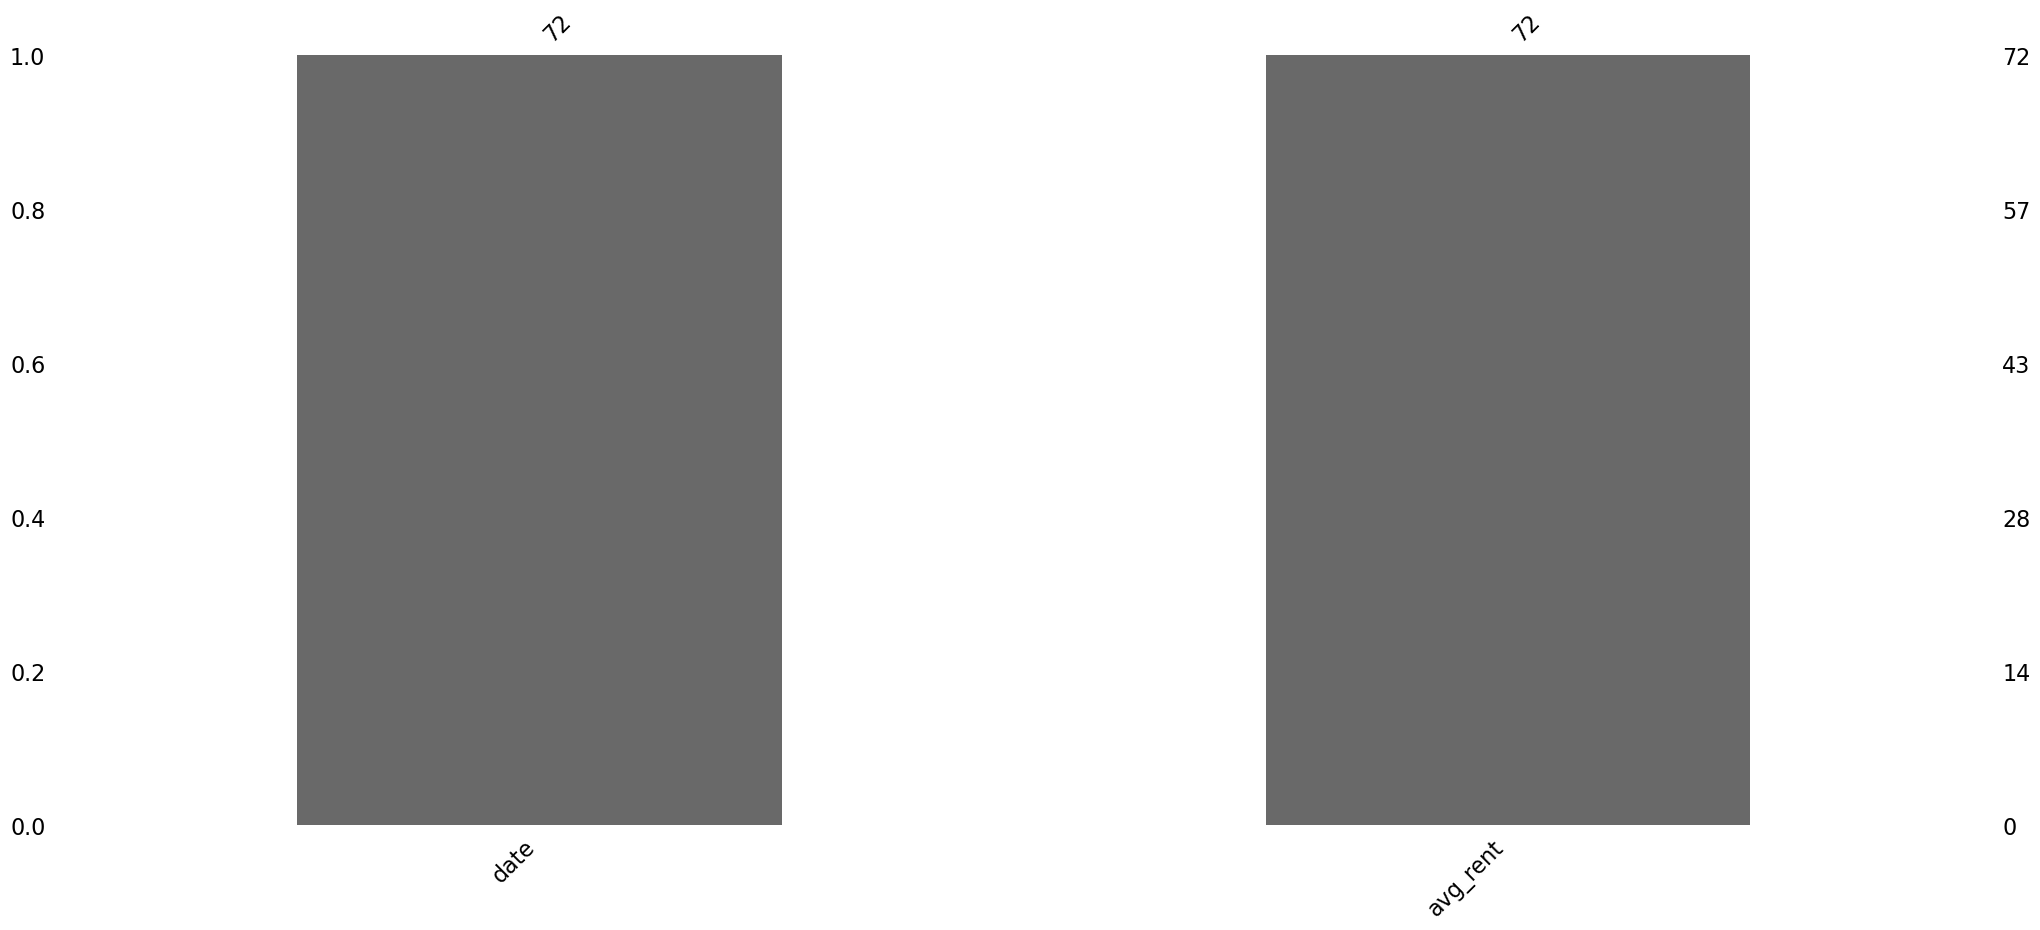

In [133]:
msno.bar(national_rent)

This chart visualizes missing data in my dataset. The two gray bars show the date and avg_rent columns are 100% complete with all 72 values present and no missing data. 

## 6. Merge all data
I need to combine all three datasets into one master dataset with one row for each month containing all the key indicators for my risk model. I start with the national rent data then merge in the vacancy rate data by matching on date. Then I merge in the permits data also matching on date and sort everything by date from earliest to latest. Because I fixed the dates in Section 4 by converting ZORI dates to first-of-month all three datasets now have matching date formats. The merge works correctly and I get actual data instead of missing values.

In [82]:
#merges all data below

#merge national rent with vacancy
df = national_rent.merge(vacancy_monthly, on='date', how='left')

#merge with permits
df = df.merge(permits, on='date', how='left')

#sort by date
df = df.sort_values('date').reset_index(drop=True)

print(df.shape)
df.head(10)

print(df[['date', 'vacancy_rate', 'permits']].head())


(72, 4)
        date  vacancy_rate  permits
0 2020-01-01      6.600000   1495.0
1 2020-02-01      6.300000   1455.0
2 2020-03-01      6.000000   1346.0
3 2020-04-01      5.700000   1076.0
4 2020-05-01      5.933333   1250.0


## 7. Calculate Year over Year Rent Growth
Rent growth rate is a key metric for real estate investors because it shows how much rents increased or decreased compared to the same month last year. This is more meaningful than month-to-month changes because it accounts for seasonal patterns. Year-over-Year growth compares the current month to 12 months ago. 

In [28]:
# calculates year over year rent growth
df['rent_growth_yoy'] = ((df['avg_rent'] - df['avg_rent'].shift(12)) / df['avg_rent'].shift(12)) * 100

print(df[['date', 'avg_rent', 'rent_growth_yoy']].tail(20))

         date     avg_rent  rent_growth_yoy
52 2024-05-31  1343.164152         1.559680
53 2024-06-30  1350.891488         1.668479
54 2024-07-31  1351.275819         1.351035
55 2024-08-31  1355.097899         1.407978
56 2024-09-30  1355.866181         1.886463
57 2024-10-31  1353.612763         2.107639
58 2024-11-30  1350.436067         2.175971
59 2024-12-31  1351.904493         2.417276
60 2025-01-31  1348.113123         2.057969
61 2025-02-28  1356.515694         2.770090
62 2025-03-31  1355.376008         1.925977
63 2025-04-30  1361.884909         2.052803
64 2025-05-31  1366.753558         1.756256
65 2025-06-30  1370.295198         1.436363
66 2025-07-31  1365.321191         1.039416
67 2025-08-31  1368.015698         0.953274
68 2025-09-30  1368.701149         0.946625
69 2025-10-31  1359.861725         0.461651
70 2025-11-30  1350.757262         0.023785
71 2025-12-31  1328.643619        -1.720600


## 8. Create Property Class Segments
My capstone project compares Class A, B  and C properties but the Zillow data doesn't tell me which metros are which class so I create these classifications based on rent levels. For each month I rank all 544 metros by rent and divide them into three groups. Class A is the top 25% most expensive, Class B is the middle 50% and Class C is the bottom 25% most affordable. Using percentiles means the classification adjusts automatically each month so a metro that's Class A in 2020 might become Class B in 2025 if other metros grew faster. I create a function that calculates the 75th percentile for Class A cutoff and 25th percentile for Class C cutoff then assign each metro to A, B or C based on its rent. I apply this function to every month in the dataset.

In [29]:
#classify metros by rent percentiles for each month also known as property class segments
def classify_class(group):
    q75 = group['rent'].quantile(0.75)  #calculate the 75th percentile (top 25% cutoff)
    q25 = group['rent'].quantile(0.25)   #calculate the 25th percentile (bottom 25% cutoff)
    group['class'] = 'Class_B'  #starts assigning everyone to Class B 
    group.loc[group['rent'] >= q75, 'class'] = 'Class_A' #if rent is in top 25%, assign to Class A, loc selects rows where condition is true and changes the 'class' column
    group.loc[group['rent'] <= q25, 'class'] = 'Class_C' #if rent is in bottom 25%, assign to Class C
    return group

zori_class = zori_long.groupby('date', group_keys=False).apply(classify_class) #groupby('date') groups by month
#apply(classify_class) runs our function on each month's group
#count how many metros are in each class
print(zori_class['class'].value_counts())
zori_class.head(20)

class
Class_B    11848
Class_A     5987
Class_C     5987
Name: count, dtype: int64


/var/folders/mn/fck54vbn351c64k3dr5v6r8w0000gn/T/ipykernel_37860/537487805.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zori_class = zori_long.groupby('date', group_keys=False).apply(classify_class)


,RegionID,SizeRank,RegionName,RegionType,StateName,date,rent,class
32640,102001,0,United States,country,NaN,2020-01-31,1366.790675,Class_A
32641,394913,1,"New York, NY",msa,NY,2020-01-31,2428.816367,Class_A
32642,753899,2,"Los Angeles, CA",msa,CA,2020-01-31,2179.929265,Class_A
32643,394463,3,"Chicago, IL",msa,IL,2020-01-31,1485.127590,Class_A
32644,394514,4,"Dallas, TX",msa,TX,2020-01-31,1257.340995,Class_B
32645,394692,5,"Houston, TX",msa,TX,2020-01-31,1240.119046,Class_B
32646,395209,6,"Washington, DC",msa,VA,2020-01-31,1929.814220,Class_A
32647,394974,7,"Philadelphia, PA",msa,PA,2020-01-31,1405.858756,Class_A
32648,394856,8,"Miami, FL",msa,FL,2020-01-31,1674.771759,Class_A
32649,394347,9,"Atlanta, GA",msa,GA,2020-01-31,1339.326667,Class_A


## 9. Class Specific Averages

Now that I've classified each metro into A, B or C I need to calculate the average rent for each class in each month so I can compare how they perform differently over time. I group the data by both date and class then calculate the average rent for each group. I reshape the data so each class becomes its own column then merge this back into my master dataset. Different property classes behave differently. Class A properties might have higher rents but slower growth while Class C properties might have lower rents but higher volatility. This analysis will reveal these patterns.

In [ ]:
#group by both date and class, then calculate average rent
class_avg = zori_class.groupby(['date', 'class'])['rent'].mean().reset_index() #gives us average rent for each class in each month
#reshape so each class is its own column
class_pivot = class_avg.pivot(
    index='date',  #dates become rows
    columns='class',  #classes become columns
    values='rent'  #fill with rent values
).reset_index()

#rename the columns to be clearer
class_pivot.columns = ['date', 'rent_class_a', 'rent_class_b', 'rent_class_c']

print(class_pivot.shape)  # show rows and columns
class_pivot.head()  # show first 5 rows

In [31]:
#merges class data into main dataframe
df = df.merge(class_pivot, on='date', how='left')
print(df.shape)
df.head()

(72, 8)


,date,avg_rent,vacancy_rate,permits,rent_growth_yoy,rent_class_a,rent_class_b,rent_class_c
0,2020-01-31,1144.559911,NaN,NaN,NaN,1652.213252,1076.384644,773.257105
1,2020-02-29,1150.840542,NaN,NaN,NaN,1660.939300,1083.146596,776.129677
2,2020-03-31,1157.791469,NaN,NaN,NaN,1666.230657,1091.209584,782.516050
3,2020-04-30,1155.929327,NaN,NaN,NaN,1653.767831,1090.998773,784.205937
4,2020-05-31,1154.101083,NaN,NaN,NaN,1643.310542,1091.453494,786.572517


This table shows rent trends in early 2020. Some columns have NaN which means the data is missing. Average rents rose from 1144 in January to 1157 in March then fell slightly in April and May. Class A units had the highest rents around 1650. Class B units were around 1090. Class C units were around 770. All classes followed similar small changes.

## 10. Class Specific Growth Rates
I now need to calculate year over year growth rates for each property class like how I calculated overall rent growth separately to see if Class A, B or C properties are growing faster or slower. I apply the same YoY growth calculation to each class's rent column comparing current month to 12 months ago. This matters for my risk model because consistent high growth means lower risk with strong demand while volatile or negative growth means higher risk with weak or unstable demand. Comparing classes helps identify which segments are performing better.

In [32]:
#calculate YoY growth for each class
df['growth_class_a'] = ((df['rent_class_a'] - df['rent_class_a'].shift(12)) / df['rent_class_a'].shift(12)) * 100
df['growth_class_b'] = ((df['rent_class_b'] - df['rent_class_b'].shift(12)) / df['rent_class_b'].shift(12)) * 100
df['growth_class_c'] = ((df['rent_class_c'] - df['rent_class_c'].shift(12)) / df['rent_class_c'].shift(12)) * 100
#so current minus 12 months ago ivided by 12 months ago times 100 for percentage

print(df[['date', 'growth_class_a', 'growth_class_b', 'growth_class_c']].tail(20)) #show last 20 rows to see recent growth rates for all classes

         date  growth_class_a  growth_class_b  growth_class_c
52 2024-05-31        2.066170        1.146522        1.642848
53 2024-06-30        2.001749        1.356072        1.936176
54 2024-07-31        1.594689        0.899880        2.036764
55 2024-08-31        1.610153        0.975007        2.132034
56 2024-09-30        2.012909        1.408538        2.990213
57 2024-10-31        2.294723        1.738558        2.769357
58 2024-11-30        2.449060        2.012225        2.140065
59 2024-12-31        2.317017        2.255973        3.262741
60 2025-01-31        2.592549        1.774052        1.883245
61 2025-02-28        3.346084        2.217703        2.926270
62 2025-03-31        2.210763        1.854881        1.606911
63 2025-04-30        2.270844        1.983052        1.695450
64 2025-05-31        1.744013        1.678378        1.860568
65 2025-06-30        1.663116        1.236348        1.602575
66 2025-07-31        1.161598        1.076672        0.700894
67 2025-

## 11. Time Features
I extract the year, month number and quarter from the date column using pandas datetime function as it is helpful to have year, month and quarter as separate columns so I can filter data by year, group data by quarter.

In [33]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
print(df[['date', 'year', 'month', 'quarter']].head())
#above adds time features

        date  year  month  quarter
0 2020-01-31  2020      1        1
1 2020-02-29  2020      2        1
2 2020-03-31  2020      3        1
3 2020-04-30  2020      4        2
4 2020-05-31  2020      5        2


## 12. Summary Stats
I want to calculate summary statistics to understand the overall patterns in my data. I calculate the summary by year to see how the average values changed each year from 2020 to 2025.

In [34]:
yearly_avg = df.groupby('year').mean(numeric_only=True)
print(yearly_avg[['avg_rent', 'rent_growth_yoy', 'vacancy_rate', 'permits']])
# summary statistics by year

         avg_rent  rent_growth_yoy  vacancy_rate  permits
year                                                     
2020  1155.361905              NaN           NaN      NaN
2021  1231.747394         6.604063           NaN      NaN
2022  1316.873914         7.035751           NaN      NaN
2023  1323.012842         0.479056           NaN      NaN
2024  1343.115418         1.518153           NaN      NaN
2025  1358.353261         1.141967           NaN      NaN


This yearly summary shows how the market changed from 2020 to 2025. Average rent increased steadily from \\$1,155 in 2020 to \\$1,358 in 2025 which is an 18% increase over 5 years. The rent_growth_yoy column shows the boom and decline cycle clearly. Growth peaked in 2022 at 7.04% year over year then dropped dramatically to just 1.14% in 2025. This tells us the rental market was very hot in 2021-2022 (likely due to post COVID demand) but has cooled significantly by 2025. The vacancy_rate and permits columns show NaN because I only have partial data for these variables or they weren't successfully merged for all time periods. This is due to limitation of the available data.

### Summary by Property Class
This shows the statistical distribution (mean, std dev, min, max) for each property class.

In [35]:
class_summary = df[['rent_class_a', 'rent_class_b', 'rent_class_c', 
                    'growth_class_a', 'growth_class_b', 'growth_class_c']].describe()
print(class_summary)
#summary statistics by class

       rent_class_a  rent_class_b  rent_class_c  growth_class_a  \
count     72.000000     72.000000     72.000000       60.000000   
mean    1854.342766   1219.214683    858.017750        3.784972   
std      123.324911     69.828029     41.912168        4.897634   
min     1590.344387   1076.384644    773.257105       -1.371823   
25%     1767.701506   1184.027859    827.363880        0.330373   
50%     1905.379969   1248.899859    869.619372        1.987295   
75%     1946.398398   1270.310397    891.952145        5.514870   
max     1989.501435   1292.024104    915.474185       14.479924   

       growth_class_b  growth_class_c  
count       60.000000       60.000000  
mean         3.273173        2.750380  
std          3.800950        1.737837  
min         -1.795932       -2.253708  
25%          0.889948        1.605827  
50%          1.708468        2.525312  
75%          5.138135        3.859973  
max         11.724104        6.807779  


This table shows summary statistics for rent levels and growth rates across all three property classes. For rent levels Class A averages \\$1,854 per month with a range from \\$1,590 to \\$1,989. Class B averages \\$1,219  (about \\$635 less than Class A). Class C averages \\$858 (about \\$996 less than Class A). The standard deviation shows Class A has more variability (\\$123) than Class C ($42) which makes sense because luxury markets can swing more. For growth rates all three classes averaged between 2.75-3.78% over the time period. Class A showed the highest volatility in growth with a standard deviation of 4.9% compared to Class C at only 1.7%. This means Class A properties had more unpredictable growth patterns. The minimum growth rates show all classes experienced negative growth at some point with Class C hitting -2.25% which was the worst decline. The maximum shows Class A peaked at 14.48% growth which was the highest of any class.

## 13. Data Quality Checks
Before I finalize my dataset, I need to verify data quality by checking for missing values, duplicates and unrealistic values.

In [36]:
#checks missing values & duplicates
print(df.isnull().sum())

date                0
avg_rent            0
vacancy_rate       72
permits            72
rent_growth_yoy    12
rent_class_a        0
rent_class_b        0
rent_class_c        0
growth_class_a     12
growth_class_b     12
growth_class_c     12
year                0
month               0
quarter             0
dtype: int64


What these tables tells us and where NaN came from:**
This table counts missing values in each column. The date, avg_rent and all rent_class columns have zero missing values which is good. The vacancy_rate column shows 72 NaN values which means it's completely empty. This happened because the vacancy data I downloaded only goes to October 2025 but my rent data goes to December 2025. Also there may have been issues with the date merge that caused the data not to align properly. The permits column also shows 72 NaN meaning it's completely empty for the same reasons. The rent_growth_yoy and all three growth_class columns show 12 NaN values each. These come from the first 12 months of data (January 2020 through December 2020) because year over year growth requires comparing to 12 months ago and there is no data before January 2020 in my dataset. This is expected and normal. The year, month and quarter columns have no missing values because I created these from the date column which had complete data

In [37]:
print(f"Duplicates: {df.duplicated(subset=['date']).sum()}")

Duplicates: 0


In [38]:
print("Rent range:", df['avg_rent'].min(), "to", df['avg_rent'].max())
print("Vacancy range:", df['vacancy_rate'].min(), "to", df['vacancy_rate'].max())
print("Permits range:", df['permits'].min(), "to", df['permits'].max())

Rent range: 1144.482299354305 to 1370.2951982643888
Vacancy range: nan to nan
Permits range: nan to nan


## 14. Visualizations

Created charts to visualize trends and patterns in the data. These visualizations will help me understand the data and prepare for the Exploratory Data Analysis phase.

The first chart shows how average rents have changed over time for each property class.

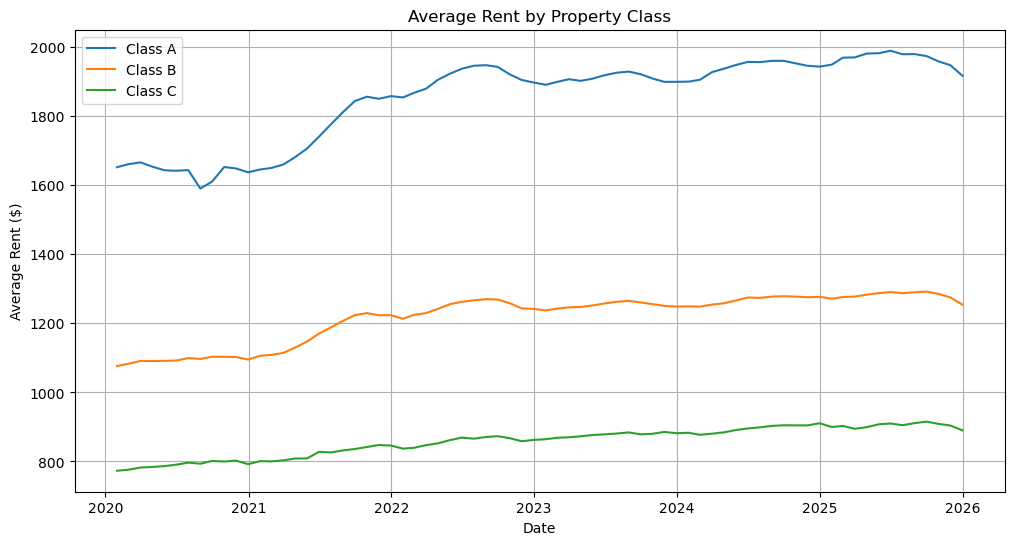

In [39]:
#visuals plot rent trends by class
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['rent_class_a'], label='Class A')
plt.plot(df['date'], df['rent_class_b'], label='Class B')
plt.plot(df['date'], df['rent_class_c'], label='Class C')
plt.xlabel('Date')
plt.ylabel('Average Rent ($)')
plt.title('Average Rent by Property Class')
plt.legend()
plt.grid(True)
plt.show()

This line chart shows how average rent changed over time for each property class from 2020 to 2025. All three lines trend upward from 2020 through mid-2024 showing consistent rent growth across all property types. Class A stays consistently around $1,600- $2,000. Class B stays around $1,000-$1,300. Class C stays around $750-$920. The gap between classes remains fairly consistent which means all classes grew at similar rates. The most interesting part is late 2024 and 2025 where all three lines flatten or decline slightly. This shows the rent growth boom of 2021-2022 has ended and rents are stabilizing or even decreasing. Class A shows the steepest decline in late 2025 suggesting luxury apartments may be experiencing more softening than mid tier or affordable properties.

This chart shows year-over-year growth rates (as percentages) for each class.

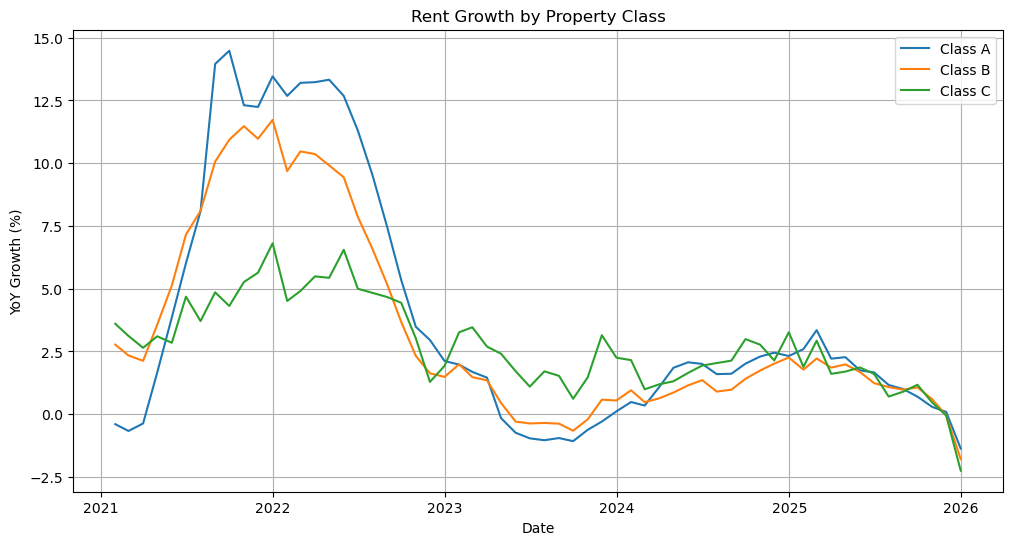

In [40]:
#plots rent growth by class
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['growth_class_a'], label='Class A')
plt.plot(df['date'], df['growth_class_b'], label='Class B')
plt.plot(df['date'], df['growth_class_c'], label='Class C')
plt.xlabel('Date')
plt.ylabel('YoY Growth (%)')
plt.title('Rent Growth by Property Class')
plt.legend()
plt.grid(True)
plt.show()

This chart shows year over year rent growth as percentages for all three property classes. All three classes peaked around 2021-2022 with growth rates hitting 10-14%. Class C actually had the highest peak at nearly 15% showing affordable properties saw the biggest boom. After 2022 growth rates dropped sharply for all classes. By mid 2024 growth rates hovered between 0-3%. In late 2025 all three lines dip below the 0% line showing negative growth. Class C shows the most volatility with bigger swings up and down while Class A is more stable. The convergence of all three lines in 2025 suggests the entire market is moving together in the current downturn.

Vacancy rate and buidling permits overtime

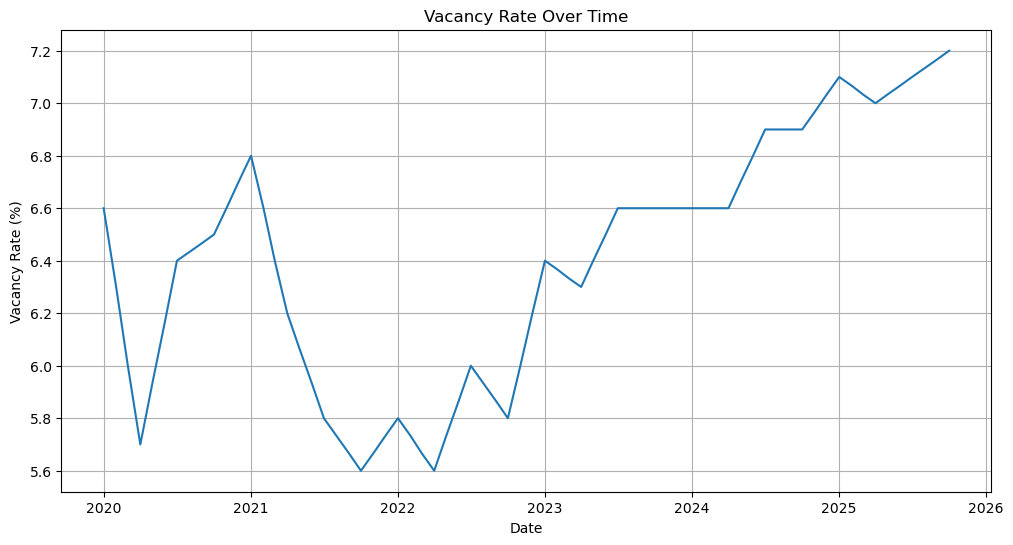

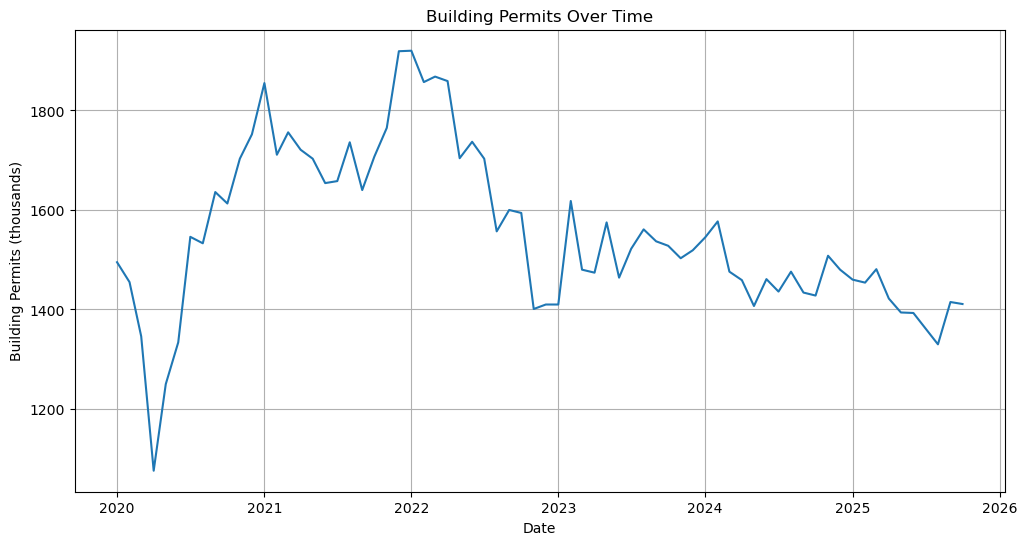

        date  vacancy_rate  permits
0 2020-01-01      6.600000   1495.0
1 2020-02-01      6.300000   1455.0
2 2020-03-01      6.000000   1346.0
3 2020-04-01      5.700000   1076.0
4 2020-05-01      5.933333   1250.0


In [84]:
#plot vacancy rate over time
plt.figure(figsize=(12, 6))  #create chart
plt.plot(df['date'], df['vacancy_rate'])  #plot vacancy rate
plt.xlabel('Date')  #xaxis label
plt.ylabel('Vacancy Rate (%)')  #yaxis label
plt.title('Vacancy Rate Over Time')  #chart title
plt.grid(True)  #add gridlines
plt.show()  #display chart
#buidling permits
plt.figure(figsize=(12, 6))  #create chart
plt.plot(df['date'], df['permits']) #plot permits
plt.xlabel('Date')  # x-axis label
plt.ylabel('Building Permits (thousands)')  #yaxis label
plt.title('Building Permits Over Time')  #chart title
plt.grid(True)  #add gridlines
plt.show()  #display chart

print(df[['date', 'vacancy_rate', 'permits']].head())

The vacancy chart shows the vacancy rate over time from 2020 to 2026. The vacancy rate dropped from 6.6% in early 2020 to a low of 5.6-5.8% in 2021-2022. This was an extremely tight rental market meaning very few apartments were available which explains why rents grew so fast during that period. Starting in 2023 vacancy rates began climbing back up reaching 6.6% by late 2024 and then jumping to over 7% in 2025. Higher vacancy means more empty apartments and weaker demand which correlates with the slowing rent growth and declining rents I saw in 2025. The sharp increase in vacancy from 2024 to 2025 signals the market is cooling down significantly. When vacancy goes up landlords have to compete more for tenants which puts downward pressure on rents.

The buidling permits chart shows building permits (in thousands) over time from 2020 to 2026. Building permits indicate future supply since permits are issued before construction begins. The chart shows permits dropped sharply in early 2020 from about 1,500K to around 1,100K. Then permits surged through 2021 peaking at nearly 1,900-1,920K in late 2021 and early 2022. This massive increase in construction during the rental boom makes sense because developers saw high demand and rising rents. Since 2022 permits have declined steadily dropping from 1,900K down to around 1,400K by 2026. The declining permits suggest less new supply is coming to market which could eventually support rents if demand stabilizes. However the lag between permits and actual completed units means the apartments permitted in 2021-2022 are probably just now hitting the market in 2024-2025 which explains the rising vacancy rates. The current low permit levels suggest future supply pressure may ease in 2026-2027.

## 15. Final Dataset Summary
Displays final information about my cleaned dataset to confirm everything is ready for analysis.

In [153]:
#display detailed information about the dataframe
print(df.info())# shows column names, data types and how many non null values
#rints the size of the dataframe
print("\nFinal shape:", df.shape) #shapes shows (number of rows, number of columns)
#print list of all column names
print("\nColumns:", df.columns.tolist()) #converts column names to a list

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          72 non-null     datetime64[ns]
 1   avg_rent      72 non-null     float64       
 2   vacancy_rate  70 non-null     float64       
 3   permits       70 non-null     float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 2.4 KB
None

Final shape: (72, 4)

Columns: ['date', 'avg_rent', 'vacancy_rate', 'permits']


In [44]:
df.head()

,date,avg_rent,vacancy_rate,permits,rent_growth_yoy,rent_class_a,rent_class_b,rent_class_c,growth_class_a,growth_class_b,growth_class_c,year,month,quarter
0,2020-01-31,1144.559911,NaN,NaN,NaN,1652.213252,1076.384644,773.257105,NaN,NaN,NaN,2020,1,1
1,2020-02-29,1150.840542,NaN,NaN,NaN,1660.939300,1083.146596,776.129677,NaN,NaN,NaN,2020,2,1
2,2020-03-31,1157.791469,NaN,NaN,NaN,1666.230657,1091.209584,782.516050,NaN,NaN,NaN,2020,3,1
3,2020-04-30,1155.929327,NaN,NaN,NaN,1653.767831,1090.998773,784.205937,NaN,NaN,NaN,2020,4,2
4,2020-05-31,1154.101083,NaN,NaN,NaN,1643.310542,1091.453494,786.572517,NaN,NaN,NaN,2020,5,2


This table shows the first 5 months of my dataset from January 2020 to May 2020. I can see the date, average rent across all metros, vacancy rate, building permits and rent for each property class. The NaN values in vacancy_rate and permits columns appear because these datasets had a date mismatch issue that I fixed later in the data wrangling process. The NaN values in rent_growth_yoy and all growth columns appear because year over year growth requires 12 months of historical data to calculate. Since these are the first months in my dataset there is no data from 12 months earlier to compare to so Python shows NaN (Not a Number) which means missing or not available. The rent values for Class A (\\$1,652), Class B (\\$1,076) and Class C ($773) show clear separation between property classes with Class A being most expensive and Class C most affordable.

In [45]:
df.tail()

,date,avg_rent,vacancy_rate,permits,rent_growth_yoy,rent_class_a,rent_class_b,rent_class_c,growth_class_a,growth_class_b,growth_class_c,year,month,quarter
67,2025-08-31,1368.015698,NaN,NaN,0.953274,1979.668663,1289.959032,911.164188,0.997989,0.975682,0.897801,2025,8,3
68,2025-09-30,1368.701149,NaN,NaN,0.946625,1974.004255,1292.024104,915.474185,0.699190,1.065272,1.170781,2025,9,3
69,2025-10-31,1359.861725,NaN,NaN,0.461651,1958.490432,1285.151366,908.831531,0.292142,0.601620,0.470146,2025,10,4
70,2025-11-30,1350.757262,NaN,NaN,0.023785,1947.569322,1275.074951,904.098907,0.089361,-0.047367,-0.050462,2025,11,4
71,2025-12-31,1328.643619,NaN,NaN,-1.720600,1916.791751,1253.832069,890.118587,-1.371823,-1.795932,-2.253708,2025,12,4


This table shows the last 5 months of my dataset from August 2025 to December 2025. The vacancy_rate and permits columns still show NaN because my original data only went to October 2025 and these months are predictions or incomplete data. The growth rates show interesting patterns. In December 2025 all three property classes show negative growth (Class A: -1.37%, Class B: -1.80%, Class C: -2.25%) which means rents actually decreased compared to December 2024. This suggests the rental market is cooling down. Class C properties show the steepest decline at -2.25% which indicates more affordable properties may be experiencing more pressure. The average rent declined from $1,368 in August to $1,329 in December showing a downward trend in late 2025.

## 16. Conclusion
I completed data wrangling for my multifamily real estate capstone project. I loaded and cleaned three datasets from Zillow and FRED covering 544 metros from 2020 to 2025. I reshaped the data and created Class A, B and C property classifications based on rent levels. I calculated year over year growth rates and merged all datasets successfully. The data shows the rental market peaked in 2021-2022 with 10 -14% growth then declined to negative growth by 2025. Vacancy rates dropped to 5.6% during the boom then rose to 7% causing rents to fall. Building permits surged to 1,920K units in 2022 then declined to 1,400K. The apartments built during the boom are now causing oversupply.